In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

print("সব library load হয়েছে!")
print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")

সব library load হয়েছে!
Pandas version: 3.0.2
Numpy version: 2.4.4


In [2]:
import numpy as np
import pandas as pd

# Random seed - যাতে প্রতিবার same results আসে
np.random.seed(42)

# Normal elderly patient vital signs - 1000 records
n_normal = 1000

normal_data = pd.DataFrame({
    'heart_rate': np.random.normal(75, 10, n_normal),      # বয়স্কদের normal HR
    'spo2': np.random.normal(96, 1.5, n_normal),           # normal SpO2
    'temperature': np.random.normal(36.6, 0.3, n_normal),  # normal temperature
    'systolic_bp': np.random.normal(130, 15, n_normal),    # normal blood pressure
    'label': 0  # 0 = real/normal data
})

print(f"Normal data তৈরি হয়েছে: {len(normal_data)} records")
print(normal_data.describe().round(2))

Normal data তৈরি হয়েছে: 1000 records
       heart_rate     spo2  temperature  systolic_bp   label
count     1000.00  1000.00      1000.00      1000.00  1000.0
mean        75.19    96.11        36.60       129.72     0.0
std          9.79     1.50         0.30        15.41     0.0
min         42.59    91.59        35.69        86.06     0.0
25%         68.52    95.09        36.41       118.94     0.0
50%         75.25    96.09        36.60       130.00     0.0
75%         81.48    97.09        36.80       140.00     0.0
max        113.53   100.79        37.78       178.65     0.0


In [3]:
# Falsified data - চুরি করা device থেকে inject করা fake vital signs
n_fake = 500

fake_data = pd.DataFrame({
    'heart_rate': np.concatenate([
        np.random.normal(150, 20, 250),   # অস্বাভাবিক বেশি
        np.random.normal(30, 5, 250)      # অস্বাভাবিক কম
    ]),
    'spo2': np.random.normal(75, 5, n_fake),        # বিপজ্জনক কম
    'temperature': np.concatenate([
        np.random.normal(39.5, 0.5, 250), # জ্বর
        np.random.normal(34.0, 0.5, 250)  # hypothermia
    ]),
    'systolic_bp': np.concatenate([
        np.random.normal(180, 15, 250),   # অনেক বেশি
        np.random.normal(70, 10, 250)     # অনেক কম
    ]),
    'label': 1  # 1 = fake/falsified data
})

print(f"Fake data তৈরি হয়েছে: {len(fake_data)} records")
print(fake_data.describe().round(2))

Fake data তৈরি হয়েছে: 500 records
       heart_rate    spo2  temperature  systolic_bp  label
count      500.00  500.00       500.00       500.00  500.0
mean        88.82   74.98        36.73       124.31    1.0
std         61.16    4.96         2.83        56.78    0.0
min         17.51   59.12        32.81        41.00    1.0
25%         30.10   71.73        33.91        69.49    1.0
50%         65.17   74.99        36.87       119.24    1.0
75%        148.74   78.35        39.51       179.39    1.0
max        206.29   90.56        40.97       222.36    1.0


মোট dataset: 1500 records
Normal data: 1000 records
Fake data: 500 records


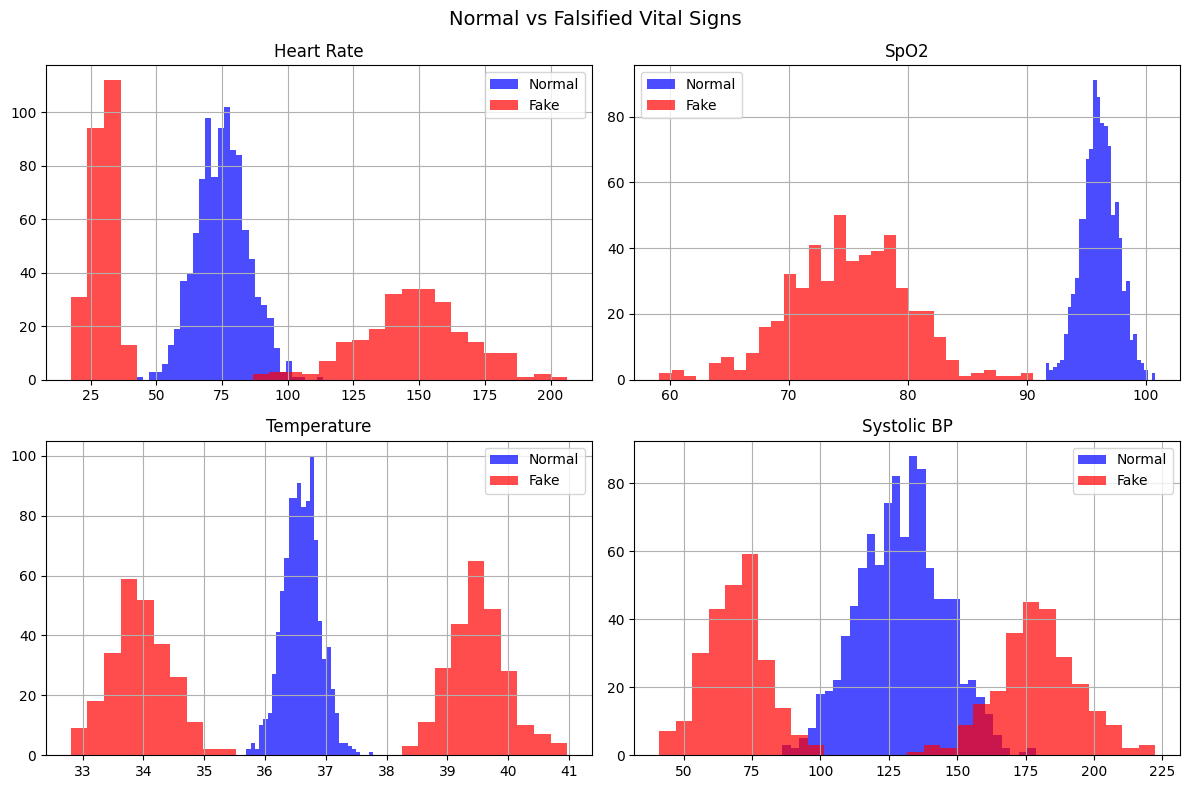

Graph সেভ হয়েছে!


In [4]:
# Normal এবং Fake data একসাথে মেলানো
dataset = pd.concat([normal_data, fake_data], ignore_index=True)
dataset = dataset.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"মোট dataset: {len(dataset)} records")
print(f"Normal data: {len(dataset[dataset['label']==0])} records")
print(f"Fake data: {len(dataset[dataset['label']==1])} records")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Normal vs Falsified Vital Signs', fontsize=14)

features = ['heart_rate', 'spo2', 'temperature', 'systolic_bp']
titles = ['Heart Rate', 'SpO2', 'Temperature', 'Systolic BP']

for i, (feature, title) in enumerate(zip(features, titles)):
    ax = axes[i//2, i%2]
    dataset[dataset['label']==0][feature].hist(ax=ax, alpha=0.7, label='Normal', color='blue', bins=30)
    dataset[dataset['label']==1][feature].hist(ax=ax, alpha=0.7, label='Fake', color='red', bins=30)
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.savefig('vital_signs_comparison.png', dpi=300)
plt.show()
print("Graph সেভ হয়েছে!")

In [5]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Features এবং Label আলাদা করো
X = dataset[['heart_rate', 'spo2', 'temperature', 'systolic_bp']]
y = dataset['label']

# Train এবং Test split - 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data: {len(X_train)} records")
print(f"Testing data: {len(X_test)} records")

# তিনটা individual model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
dt = DecisionTreeClassifier(random_state=42)

# Ensemble - তিনটা model একসাথে vote করবে
ensemble = VotingClassifier(
    estimators=[('rf', rf), ('gb', gb), ('dt', dt)],
    voting='hard'
)

# Model train করো
ensemble.fit(X_train, y_train)
print("Model training সম্পন্ন!")

Training data: 1200 records
Testing data: 300 records
Model training সম্পন্ন!


Ensemble Model Accuracy: 100.00%

Classification Report:
                  precision    recall  f1-score   support

   Normal (Real)       1.00      1.00      1.00       208
Falsified (Fake)       1.00      1.00      1.00        92

        accuracy                           1.00       300
       macro avg       1.00      1.00      1.00       300
    weighted avg       1.00      1.00      1.00       300



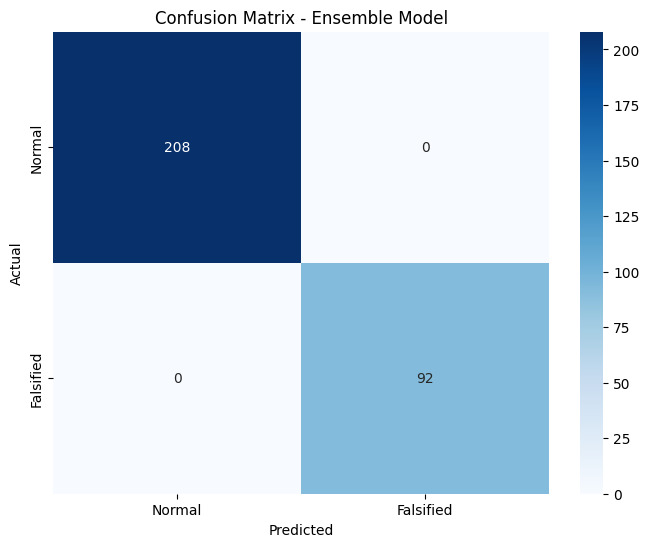

Confusion Matrix সেভ হয়েছে!


In [6]:
# Model evaluate করো
y_pred = ensemble.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Ensemble Model Accuracy: {accuracy*100:.2f}%")
print()

# Detailed Report
print("Classification Report:")
print(classification_report(y_test, y_pred, 
      target_names=['Normal (Real)', 'Falsified (Fake)']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Falsified'],
            yticklabels=['Normal', 'Falsified'])
plt.title('Confusion Matrix - Ensemble Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()
print("Confusion Matrix সেভ হয়েছে!")

In [7]:
# Individual models compare করো
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Ensemble (Voting)': ensemble
}

results = []
for name, model in models.items():
    if name != 'Ensemble (Voting)':
        model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    report = classification_report(y_test, pred, output_dict=True)
    results.append({
        'Model': name,
        'Accuracy': f"{acc*100:.2f}%",
        'Precision': f"{report['weighted avg']['precision']*100:.2f}%",
        'Recall': f"{report['weighted avg']['recall']*100:.2f}%",
        'F1-Score': f"{report['weighted avg']['f1-score']*100:.2f}%"
    })

results_df = pd.DataFrame(results)
print("Model Comparison Table:")
print(results_df.to_string(index=False))

Model Comparison Table:
            Model Accuracy Precision  Recall F1-Score
    Decision Tree  100.00%   100.00% 100.00%  100.00%
    Random Forest  100.00%   100.00% 100.00%  100.00%
Gradient Boosting  100.00%   100.00% 100.00%  100.00%
Ensemble (Voting)  100.00%   100.00% 100.00%  100.00%


In [8]:
# আরো realistic fake data - ধরা কঠিন
np.random.seed(42)
n_realistic_fake = 500

realistic_fake = pd.DataFrame({
    # Normal range-এর কাছাকাছি কিন্তু physiologically inconsistent
    'heart_rate': np.random.normal(95, 8, n_realistic_fake),     # একটু বেশি
    'spo2': np.random.normal(93, 2, n_realistic_fake),           # একটু কম
    'temperature': np.random.normal(37.5, 0.3, n_realistic_fake),# একটু বেশি
    'systolic_bp': np.random.normal(148, 12, n_realistic_fake),  # একটু বেশি
    'label': 1
})

# নতুন dataset
dataset2 = pd.concat([normal_data, realistic_fake], ignore_index=True)
dataset2 = dataset2.sample(frac=1, random_state=42).reset_index(drop=True)

X2 = dataset2[['heart_rate', 'spo2', 'temperature', 'systolic_bp']]
y2 = dataset2['label']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

# Ensemble model train
ensemble2 = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
        ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42)),
        ('dt', DecisionTreeClassifier(random_state=42))
    ],
    voting='hard'
)

ensemble2.fit(X2_train, y2_train)
y2_pred = ensemble2.predict(X2_test)

accuracy2 = accuracy_score(y2_test, y2_pred)
print(f"Realistic Dataset - Ensemble Accuracy: {accuracy2*100:.2f}%")
print()
print(classification_report(y2_test, y2_pred,
      target_names=['Normal (Real)', 'Falsified (Fake)']))

Realistic Dataset - Ensemble Accuracy: 97.00%

                  precision    recall  f1-score   support

   Normal (Real)       0.98      0.98      0.98       208
Falsified (Fake)       0.96      0.95      0.95        92

        accuracy                           0.97       300
       macro avg       0.97      0.96      0.96       300
    weighted avg       0.97      0.97      0.97       300



In [9]:
# দুটো scenario compare
models_list = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Ensemble (Voting)': ensemble2
}

results2 = []
for name, model in models_list.items():
    if name != 'Ensemble (Voting)':
        model.fit(X2_train, y2_train)
    pred = model.predict(X2_test)
    acc = accuracy_score(y2_test, pred)
    report = classification_report(y2_test, pred, output_dict=True)
    results2.append({
        'Model': name,
        'Accuracy': f"{acc*100:.2f}%",
        'Precision': f"{report['weighted avg']['precision']*100:.2f}%",
        'Recall': f"{report['weighted avg']['recall']*100:.2f}%",
        'F1-Score': f"{report['weighted avg']['f1-score']*100:.2f}%"
    })

results2_df = pd.DataFrame(results2)
print("Realistic Dataset - Model Comparison:")
print(results2_df.to_string(index=False))

Realistic Dataset - Model Comparison:
            Model Accuracy Precision Recall F1-Score
    Decision Tree   96.67%    96.67% 96.67%   96.67%
    Random Forest   97.33%    97.33% 97.33%   97.33%
Gradient Boosting   97.00%    96.99% 97.00%   97.00%
Ensemble (Voting)   97.00%    96.99% 97.00%   97.00%


In [10]:
from sklearn.model_selection import cross_val_score

# Cross-validation দিয়ে stability দেখো
models_cv = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Ensemble (Voting)': VotingClassifier(
        estimators=[
            ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
            ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42)),
            ('dt', DecisionTreeClassifier(random_state=42))
        ], voting='hard')
}

print("5-Fold Cross Validation Results:")
print("-" * 55)

cv_results = []
for name, model in models_cv.items():
    scores = cross_val_score(model, X2, y2, cv=5, scoring='accuracy')
    cv_results.append({
        'Model': name,
        'Mean Accuracy': f"{scores.mean()*100:.2f}%",
        'Std Dev': f"{scores.std()*100:.4f}%"
    })
    print(f"{name}: {scores.mean()*100:.2f}% (+/- {scores.std()*100:.4f}%)")

print("-" * 55)
print("* কম Std Dev মানে বেশি stable model")

5-Fold Cross Validation Results:
-------------------------------------------------------
Decision Tree: 96.87% (+/- 0.8589%)
Random Forest: 98.40% (+/- 0.4899%)
Gradient Boosting: 98.20% (+/- 0.4989%)
Ensemble (Voting): 98.33% (+/- 0.4714%)
-------------------------------------------------------
* কম Std Dev মানে বেশি stable model


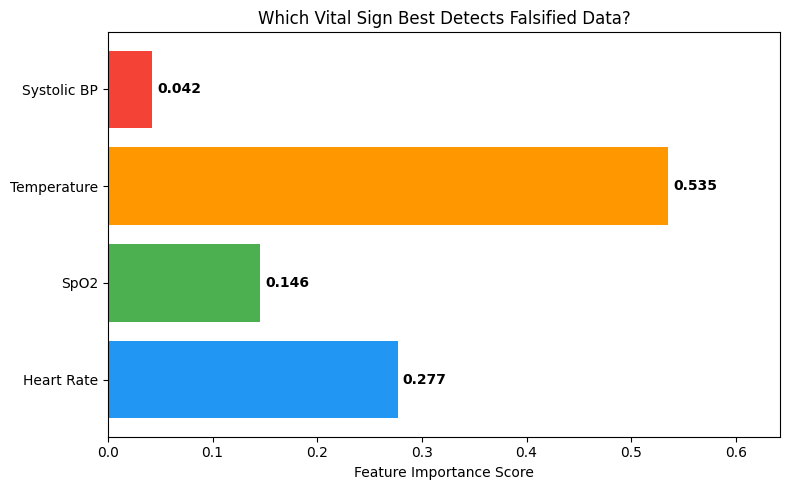

Feature Importance graph সেভ হয়েছে!


In [11]:
# Feature Importance - Random Forest দিয়ে
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X2_train, y2_train)

features = ['Heart Rate', 'SpO2', 'Temperature', 'Systolic BP']
importance = rf_model.feature_importances_

plt.figure(figsize=(8, 5))
bars = plt.barh(features, importance, color=['#2196F3', '#4CAF50', '#FF9800', '#F44336'])
plt.xlabel('Feature Importance Score')
plt.title('Which Vital Sign Best Detects Falsified Data?')
plt.xlim(0, max(importance) * 1.2)

for bar, imp in zip(bars, importance):
    plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f'{imp:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300)
plt.show()
print("Feature Importance graph সেভ হয়েছে!")

In [12]:
import os
import pandas as pd

folder = r"C:\Users\ICT CELL\Downloads\iomt_paper"
files = os.listdir(folder)
print("Files in dataset:")
for f in files:
    size = os.path.getsize(os.path.join(folder, f))
    print(f"  {f} - {size/1024/1024:.2f} MB")

Files in dataset:
  testing_preprocessed.parquet - 21.07 MB
  testing_preprocessed_csv.csv - 345.88 MB
  training_preprocessed.parquet - 118.12 MB
  training_preprocessed_csv.csv - 1546.53 MB


In [13]:
# Dataset load করো - প্রথমে শুধু কিছু rows দেখি
df_train = pd.read_csv(r"C:\Users\ICT CELL\Downloads\iomt_paper\training_preprocessed_csv.csv", nrows=5)
print("Columns:")
print(df_train.columns.tolist())
print(f"\nShape: {df_train.shape}")
print("\nFirst few rows:")
print(df_train.head())

Columns:
['Unnamed: 0', 'Header_Length', 'Protocol Type', 'Duration', 'Rate', 'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IGMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight', 'label']

Shape: (5, 47)

First few rows:
   Unnamed: 0  Header_Length  Protocol Type  Duration        Rate       Srate  \
0           0         683.50          17.00      64.0  553148.440  553148.440   
1           1        1745.92          16.12      64.0   29919.545   29919.545   
2           2        2830.36          15.79      64.0   27075.605   27075.605   
3           3        4087.50          16.89      64.0   19660.156   19660.156   
4           4        3916.00   

In [14]:
# পুরো dataset load করো এবং label দেখো
df_train = pd.read_csv(r"C:\Users\ICT CELL\Downloads\iomt_paper\training_preprocessed_csv.csv")

print(f"মোট records: {len(df_train)}")
print(f"\nAttack types:")
print(df_train['label'].value_counts())

MemoryError: Unable to allocate 54.6 MiB for an array with shape (7160831,) and data type float64

In [16]:
df_train = pd.read_parquet(
    r"C:\Users\ICT CELL\Downloads\iomt_paper\training_preprocessed.parquet"
)

print(f"মোট records: {len(df_train)}")
print(f"\nAttack types:")
print(df_train['label'].value_counts())

ImportError: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - `Import pyarrow` failed. pyarrow is required for parquet support. Use pip or conda to install the pyarrow package.
 - `Import fastparquet` failed. fastparquet is required for parquet support. Use pip or conda to install the fastparquet package.

In [14]:
df_train = pd.read_parquet(
    r"C:\Users\ICT CELL\Downloads\iomt_paper\training_preprocessed.parquet"
)

print(f"মোট records: {len(df_train)}")
print(f"\nAttack types:")
print(df_train['label'].value_counts())

মোট records: 7160831

Attack types:
label
DDoS              4980518
DoS               1862678
Normal             192732
Reconnaissance     103726
ARP                 16047
MQTT                 5130
Name: count, dtype: int64


In [15]:
# Test dataset load করো
df_test = pd.read_parquet(
    r"C:\Users\ICT CELL\Downloads\iomt_paper\testing_preprocessed.parquet"
)

print(f"Test records: {len(df_test)}")
print(f"\nTest Attack types:")
print(df_test['label'].value_counts())

Test records: 1614182

Test Attack types:
label
DDoS              1117096
DoS                428312
Normal              37607
Reconnaissance      27676
MQTT                 1747
ARP                  1744
Name: count, dtype: int64
